In [1]:
!pip install duckdb pandas matplotlib seaborn --quiet


This installs:

duckdb → SQL engine

pandas → data analysis

matplotlib & seaborn → visualization

DuckDB is important because it works like Snowflake SQL.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")


Libraries loaded successfully


In [5]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
# Keep required columns
df = df[['CustomerID', 'InvoiceDate', 'Quantity', 'UnitPrice']]

# Remove null customer IDs
df = df.dropna(subset=['CustomerID'])

# Create transaction amount
df['TransactionAmount'] = df['Quantity'] * df['UnitPrice']

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Rename columns professionally
df.columns = ['customer_id', 'transaction_date', 'quantity', 'unit_price', 'amount']

# Reset index
df = df.reset_index(drop=True)

df.head()


,customer_id,transaction_date,quantity,unit_price,amount
0,17850.0,2010-12-01 08:26:00,6,2.55,15.30
1,17850.0,2010-12-01 08:26:00,6,3.39,20.34
2,17850.0,2010-12-01 08:26:00,8,2.75,22.00
3,17850.0,2010-12-01 08:26:00,6,3.39,20.34
4,17850.0,2010-12-01 08:26:00,6,3.39,20.34


In [7]:
df.shape

(406829, 5)

In [8]:
con = duckdb.connect()

con.register("transactions", df)

print("Dataset loaded into SQL engine successfully")


Dataset loaded into SQL engine successfully


In [9]:
query = """
SELECT
COUNT(*) as total_transactions,
COUNT(DISTINCT customer_id) as total_customers,
SUM(amount) as total_revenue,
AVG(amount) as avg_transaction_value
FROM transactions
"""

result = con.execute(query).fetchdf()

result

#This calculates the basic banking KPIs

,total_transactions,total_customers,total_revenue,avg_transaction_value
0,406829,4372,8300065.814,20.401854


In [12]:
query = """
SELECT
customer_id,
COUNT(*) as total_transactions,
SUM(amount) as total_spend,
AVG(amount) as avg_transaction
FROM transactions
GROUP BY customer_id
ORDER BY total_spend DESC
"""

customer_metrics = con.execute(query).fetchdf()

customer_metrics.head()

#This identifies high-value customers

,customer_id,total_transactions,total_spend,avg_transaction
0,14646.0,2085,279489.02,134.047492
1,18102.0,433,256438.49,592.236697
2,17450.0,351,187482.17,534.137236
3,14911.0,5903,132572.62,22.458516
4,12415.0,778,123725.45,159.030141


In [13]:
customer_metrics['segment'] = pd.qcut(
    customer_metrics['total_spend'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_metrics.head()

#This creates professional segmentation.

,customer_id,total_transactions,total_spend,avg_transaction,segment
0,14646.0,2085,279489.02,134.047492,High Value
1,18102.0,433,256438.49,592.236697,High Value
2,17450.0,351,187482.17,534.137236,High Value
3,14911.0,5903,132572.62,22.458516,High Value
4,12415.0,778,123725.45,159.030141,High Value


In [18]:
segment_summary = customer_metrics.groupby('segment', observed=True).agg({
    'customer_id':'count',
    'total_spend':'sum'
}).reset_index()



#This shows the revenue contribution per segment

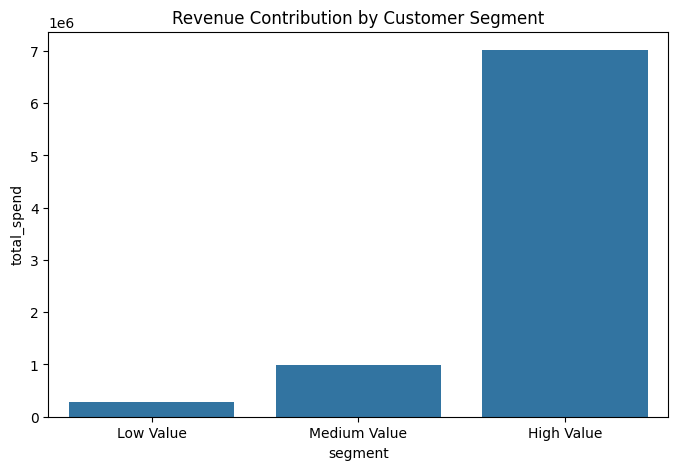

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=segment_summary, x='segment', y='total_spend')
plt.title("Revenue Contribution by Customer Segment")
plt.show()


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


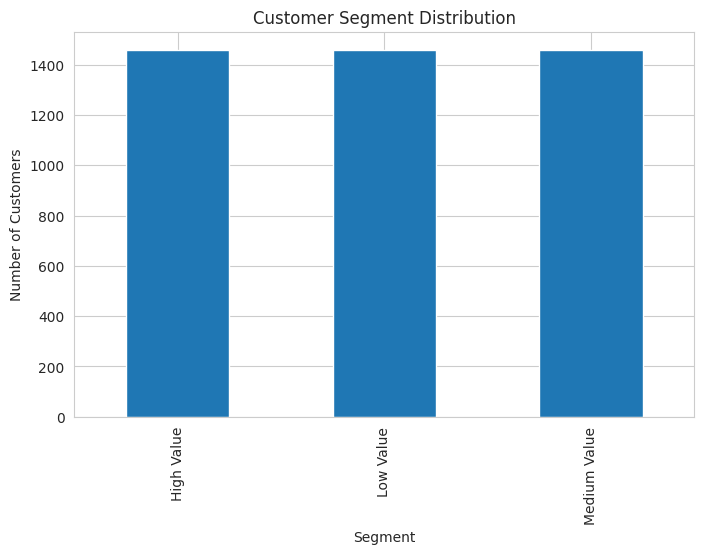

In [20]:
plt.figure(figsize=(8,5))

customer_metrics['segment'].value_counts().plot(kind='bar')

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()


This chart shows customer distribution across risk/value segments. This helps business identify high-value customers and prioritize retention strategies

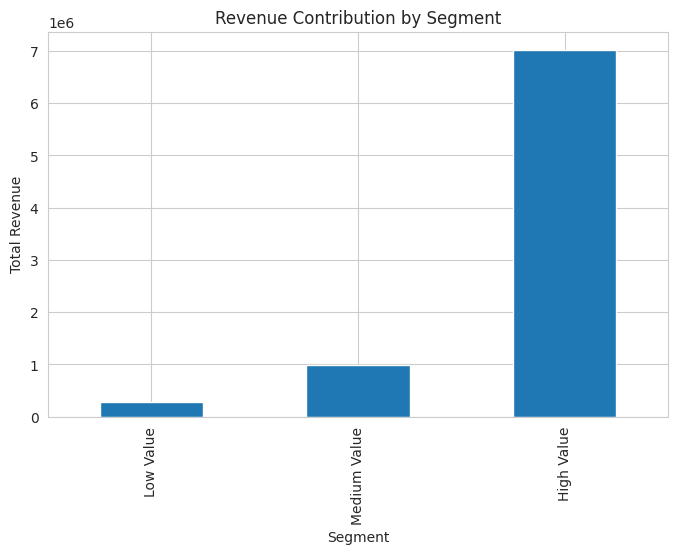

In [25]:
segment_revenue = customer_metrics.groupby('segment', observed=True)['total_spend'].sum()

plt.figure(figsize=(8,5))
segment_revenue.plot(kind='bar')

plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.show()



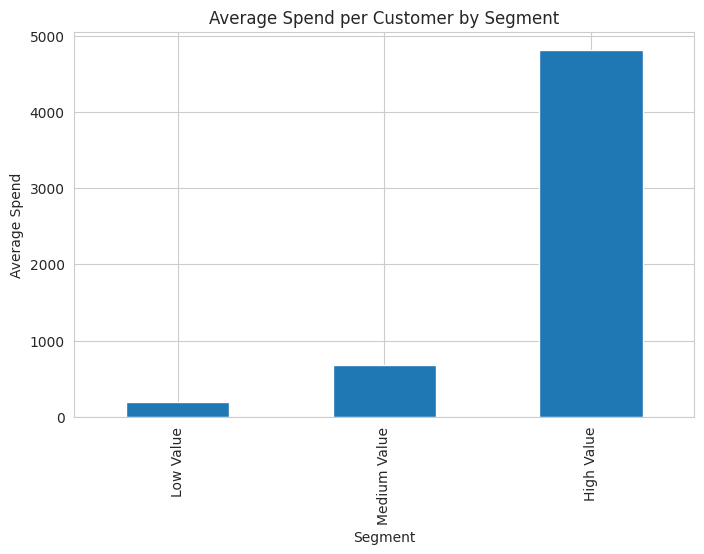

In [26]:
avg_spend = customer_metrics.groupby('segment', observed=True)['total_spend'].mean()

plt.figure(figsize=(8,5))
avg_spend.plot(kind='bar')

plt.title("Average Spend per Customer by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Spend")

plt.show()



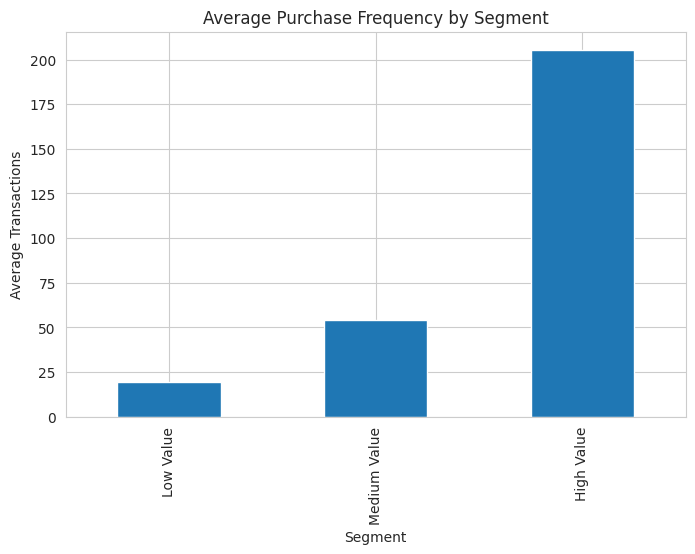

In [27]:
avg_freq = customer_metrics.groupby('segment', observed=True)['total_transactions'].mean()

plt.figure(figsize=(8,5))
avg_freq.plot(kind='bar')

plt.title("Average Purchase Frequency by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Transactions")

plt.show()



In [28]:
customer_metrics.columns

Index(['customer_id', 'total_transactions', 'total_spend', 'avg_transaction',
       'segment'],
      dtype='object')

In [29]:
import sqlite3

# create database
conn = sqlite3.connect('customer_segmentation.db')

# load raw transactional data into SQL
df.to_sql('transactions', conn, if_exists='replace', index=False)

print("Data loaded into SQL database successfully")


Data loaded into SQL database successfully


In [30]:
query = "SELECT * FROM transactions LIMIT 5"

sql_df = pd.read_sql(query, conn)

sql_df.head()


,customer_id,transaction_date,quantity,unit_price,amount
0,17850.0,2010-12-01 08:26:00,6,2.55,15.30
1,17850.0,2010-12-01 08:26:00,6,3.39,20.34
2,17850.0,2010-12-01 08:26:00,8,2.75,22.00
3,17850.0,2010-12-01 08:26:00,6,3.39,20.34
4,17850.0,2010-12-01 08:26:00,6,3.39,20.34


In [32]:
query = """
SELECT
    customer_id,
    COUNT(*) as total_transactions,
    SUM(quantity * unit_price) as total_spend,
    AVG(quantity * unit_price) as avg_transaction_value
FROM transactions
GROUP BY customer_id
"""

customer_kpi_sql = pd.read_sql(query, conn)

customer_kpi_sql.head()



,customer_id,total_transactions,total_spend,avg_transaction_value
0,12346.0,2,0.00,0.000000
1,12347.0,182,4310.00,23.681319
2,12348.0,31,1797.24,57.975484
3,12349.0,73,1757.55,24.076027
4,12350.0,17,334.40,19.670588


In [33]:
customer_kpi_sql['segment'] = pd.qcut(
    customer_kpi_sql['total_spend'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_kpi_sql.head()


,customer_id,total_transactions,total_spend,avg_transaction_value,segment
0,12346.0,2,0.00,0.000000,Low Value
1,12347.0,182,4310.00,23.681319,High Value
2,12348.0,31,1797.24,57.975484,High Value
3,12349.0,73,1757.55,24.076027,High Value
4,12350.0,17,334.40,19.670588,Low Value


In [34]:
segment_summary_sql = customer_kpi_sql.groupby('segment', observed=True).agg({
    'customer_id': 'count',
    'total_spend': 'sum',
    'total_transactions': 'mean'
}).reset_index()

segment_summary_sql


,segment,customer_id,total_spend,total_transactions
0,Low Value,1457,285412.410,19.451613
1,Medium Value,1457,997513.773,54.308854
2,High Value,1458,7017139.631,205.322359


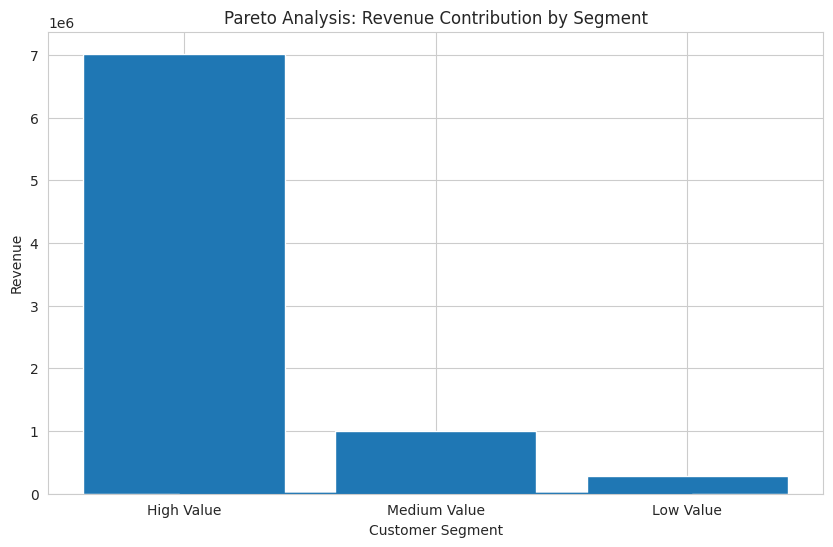

In [35]:
segment_revenue = customer_metrics.groupby('segment', observed=False)['total_spend'].sum().sort_values(ascending=False)

cumulative_pct = segment_revenue.cumsum() / segment_revenue.sum() * 100

plt.figure(figsize=(10,6))

plt.bar(segment_revenue.index, segment_revenue.values)
plt.plot(segment_revenue.index, cumulative_pct.values, marker='o')

plt.title("Pareto Analysis: Revenue Contribution by Segment")
plt.ylabel("Revenue")
plt.xlabel("Customer Segment")

plt.show()


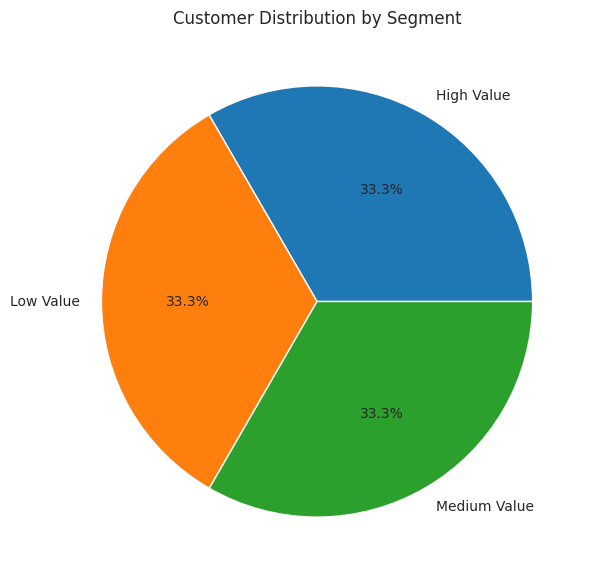

In [36]:
customer_metrics['segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7),
    title="Customer Distribution by Segment"
)

plt.ylabel("")
plt.show()


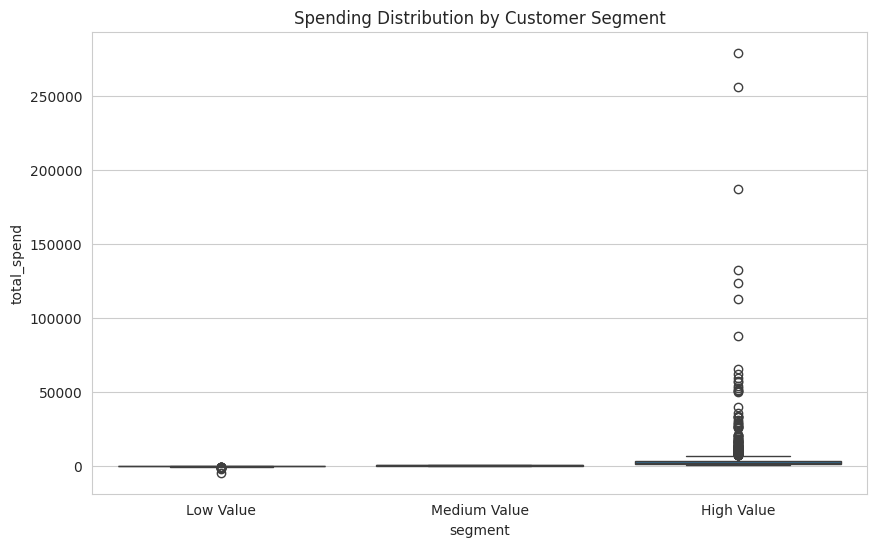

In [37]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    x='segment',
    y='total_spend',
    data=customer_metrics
)

plt.title("Spending Distribution by Customer Segment")

plt.show()


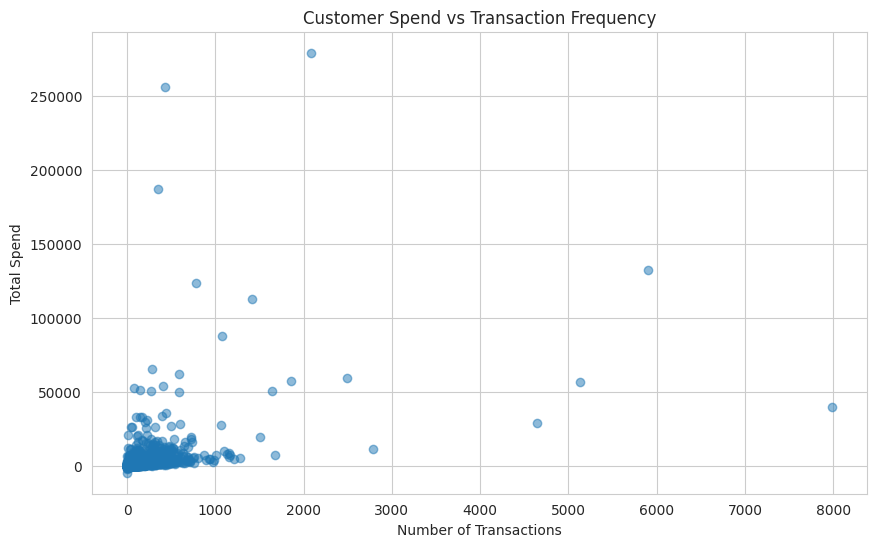

In [38]:
plt.figure(figsize=(10,6))

plt.scatter(
    customer_metrics['total_transactions'],
    customer_metrics['total_spend'],
    alpha=0.5
)

plt.title("Customer Spend vs Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")

plt.show()


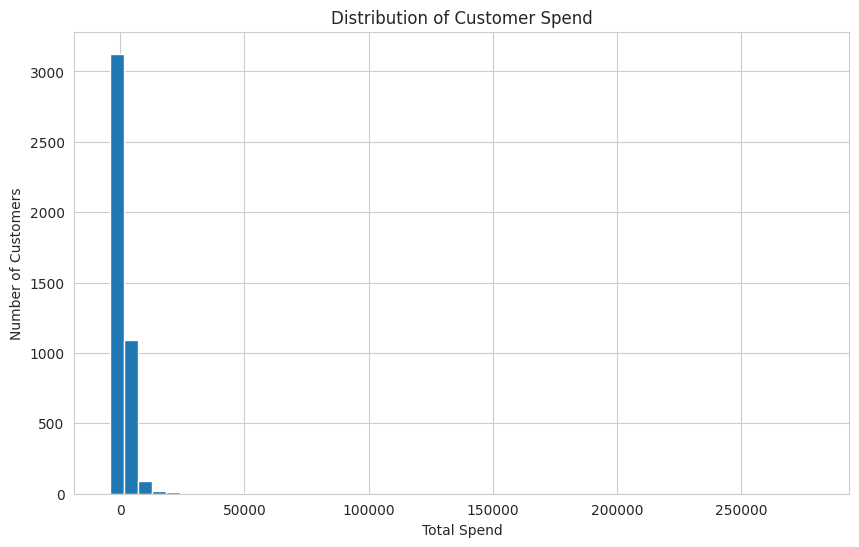

In [39]:
plt.figure(figsize=(10,6))

plt.hist(customer_metrics['total_spend'], bins=50)

plt.title("Distribution of Customer Spend")

plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")

plt.show()


In [40]:
segment_summary = customer_metrics.groupby('segment', observed=False).agg(
    total_customers=('customer_id', 'count'),
    total_revenue=('total_spend', 'sum'),
    avg_customer_value=('total_spend', 'mean'),
    avg_transactions=('total_transactions', 'mean')
).reset_index()

segment_summary


,segment,total_customers,total_revenue,avg_customer_value,avg_transactions
0,Low Value,1457,285412.410,195.890467,19.451613
1,Medium Value,1457,997513.773,684.635397,54.308854
2,High Value,1458,7017139.631,4812.852971,205.322359


In [41]:
segment_summary['revenue_contribution_pct'] = (
    segment_summary['total_revenue'] / segment_summary['total_revenue'].sum()
) * 100

segment_summary


,segment,total_customers,total_revenue,avg_customer_value,avg_transactions,revenue_contribution_pct
0,Low Value,1457,285412.410,195.890467,19.451613,3.438676
1,Medium Value,1457,997513.773,684.635397,54.308854,12.018143
2,High Value,1458,7017139.631,4812.852971,205.322359,84.543181


# Executive Business Insights

## Key Findings:

• High Value customers contribute the majority of total revenue despite equal population segmentation.

• Customer spend follows a right-skewed distribution, indicating revenue concentration among a small group.

• Transaction frequency positively correlates with customer spend, highlighting engagement-driven revenue growth.

## Business Recommendations:

• Prioritize retention strategies for High Value customers to maximize revenue stability.

• Develop targeted campaigns to convert Medium Value customers into High Value segment.

• Optimize operational cost strategies for Low Value segment customers.

## Business Impact:

This segmentation framework enables data-driven customer targeting, improves marketing efficiency, and supports strategic revenue optimization.


In [45]:
segment_summary.to_csv("customer_segment_kpi_summary.csv", index=False)